In [54]:
!pip install black
!pip install "black[jupyter]"

In [55]:
!black 'Фрукты.ipynb'

reformatted Фрукты.ipynb

All done! ✨ 🍰 ✨
1 file reformatted.


Импорты

In [3]:
import os
import wandb
import numpy as np
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
import torchvision.transforms as transforms
from sklearn.metrics import classification_report

try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary
!pip install -q --upgrade wandb
import matplotlib.pyplot as plt

%matplotlib inline

Дальше фиксируем сиды для воспроизводжимости

In [4]:
def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

создаем конфиг, прописываем инфрмацию для подключения к wandb и также прописываем список классов, с которыми булем работать, также 15% трейна отдаем на валидацию

In [5]:
class CFG:
    api = " "
    project = "last"
    entity = "statevaleksandr-hse-university"
    num_epochs = 5
    train_batch_size = 64
    test_batch_size = 256
    num_workers = 0
    lr = 3e-4
    seed = 42
    image_size = 128
    val_size = 0.15
    max_train_per_class = 200
    max_test_per_class = 80
    classes = (
        "Almonds 1",
        "Apple Granny Smith 1",
        "Apricot 1",
        "Avocado 1",
        "Beetroot 1",
        "Banana 1",
        "Banana Red 1",
        "Cabbage red 1",
        "Orange 2",
        "Lemon 1",
        "Limes 1",
        "Clementine 1",
        "Pear 1",
        "Cherry 1",
        "Cocos 1",
        "Carrot 1",
        "Pear Red 1",
        "Corn 1",
        "Tomato 1",
        "Grape 1",
        "Kiwi 1",
        "Nectarine 1",
        "Nut 1",
        "Peach 1",
        "Tomato Heart 1",
        "Cucumber 1",
        "Watermelon 1",
        "Raspberry 1",
        "Potato Red 1",
        "Potato White 1",
        "Onion Red 1",
        "Onion White 1",
        "Plum 1",
        "Pepper Red 1",
        "Pepper Green 1",
        "Pepper Yellow 1",
    )
    wandb = True

переведем класс с параметрами в словарь

In [6]:
def class2dict(f):
    return dict(
        (name, getattr(f, name)) for name in dir(f) if not name.startswith("__")
    )

In [7]:
seed_everything(CFG.seed)

Дальше подколючаемся к google drive, чтобы работать с датасетом, который загружен туда в zip

In [8]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


обратимся к датасету и распакуем его

In [9]:
if not os.path.exists("/content/data/fruits-360/Training"):
    !mkdir -p /content/data
    !unzip -oq "/content/drive/MyDrive/fruits-360_100x100.zip" -d /content/data
else:
    print("Датасет уже был распакован")

Датасет уже был распакован


дальше укажем пути к данным и проверим все ли пути определены

In [10]:
INPUT_DIR = "/content/data/fruits-360"
TRAIN_DIR = os.path.join(INPUT_DIR, "Training")
TEST_DIR = os.path.join(INPUT_DIR, "Test")

print(TRAIN_DIR)
print(TEST_DIR)
print(os.path.exists(TRAIN_DIR), os.path.exists(TEST_DIR))

/content/data/fruits-360/Training
/content/data/fruits-360/Test
True True


определим поканальные значения среднего и стандартного отклонения для ImageNet, также проверим доступность gpu с cuda и для более быстрой работы будем обучать на gpu

In [11]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
BATCH_SIZE = CFG.train_batch_size
print("device:", DEVICE)

device: cuda


Далее выполним трансформации, на валидации кроме изменения размера ничего не добавляем, потому что мы должны проверить модели на реальных картинках

In [12]:
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.Resize((CFG.image_size, CFG.image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((CFG.image_size, CFG.image_size)),
            transforms.CenterCrop(CFG.image_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    ),
}

In [13]:
dataset = {
    "train_for_train": datasets.ImageFolder(
        root=TRAIN_DIR, transform=data_transforms["train"]
    ),
    "train_for_val": datasets.ImageFolder(
        root=TRAIN_DIR, transform=data_transforms["val"]
    ),
    "test_for_test": datasets.ImageFolder(
        root=TEST_DIR, transform=data_transforms["val"]
    ),
}

dataset_size = {ds: len(dataset[ds]) for ds in dataset}
dataset_classes = dataset["train_for_train"].classes
print("Классы:", len(dataset_classes), "\nРазмер:", dataset_size)

Классы: 257 
Размер: {'train_for_train': 135071, 'train_for_val': 135071, 'test_for_test': 45008}


Дальше найдем по названиям все классы и совпадения с теми, которые мы указали в конфиге и выведем их, должно быть 36

In [14]:
all_classes = set(dataset["train_for_train"].classes)
loosing = [i for i in CFG.classes if i not in all_classes]
chosen = [j for j in CFG.classes if j in all_classes]
print("Отсутствующие классы", loosing)
print("Выбранные классы", len(chosen))
print(chosen)

Отсутствующие классы []
Выбранные классы 36
['Almonds 1', 'Apple Granny Smith 1', 'Apricot 1', 'Avocado 1', 'Beetroot 1', 'Banana 1', 'Banana Red 1', 'Cabbage red 1', 'Orange 2', 'Lemon 1', 'Limes 1', 'Clementine 1', 'Pear 1', 'Cherry 1', 'Cocos 1', 'Carrot 1', 'Pear Red 1', 'Corn 1', 'Tomato 1', 'Grape 1', 'Kiwi 1', 'Nectarine 1', 'Nut 1', 'Peach 1', 'Tomato Heart 1', 'Cucumber 1', 'Watermelon 1', 'Raspberry 1', 'Potato Red 1', 'Potato White 1', 'Onion Red 1', 'Onion White 1', 'Plum 1', 'Pepper Red 1', 'Pepper Green 1', 'Pepper Yellow 1']


Дальше нужно разобраться с индексами, потому что ImageFolder пронумеровал все 257 классов, но наши выбранные классы не идут по порядку, нужна нумерация от 0 до 35, будем искать с помощью class_to_idx

In [15]:
oldid = dataset["train_for_train"].class_to_idx
chosen_oldid = [oldid[i] for i in chosen]
newid = {i: j for j, i in enumerate(chosen)}

old_to_new = {oldid[i]: newid[i] for i in chosen}
dataset_classes = chosen
n = len(dataset_classes)

print("Число классов:", n)
print("Все классы:", dataset_classes)

Число классов: 36
Все классы: ['Almonds 1', 'Apple Granny Smith 1', 'Apricot 1', 'Avocado 1', 'Beetroot 1', 'Banana 1', 'Banana Red 1', 'Cabbage red 1', 'Orange 2', 'Lemon 1', 'Limes 1', 'Clementine 1', 'Pear 1', 'Cherry 1', 'Cocos 1', 'Carrot 1', 'Pear Red 1', 'Corn 1', 'Tomato 1', 'Grape 1', 'Kiwi 1', 'Nectarine 1', 'Nut 1', 'Peach 1', 'Tomato Heart 1', 'Cucumber 1', 'Watermelon 1', 'Raspberry 1', 'Potato Red 1', 'Potato White 1', 'Onion Red 1', 'Onion White 1', 'Plum 1', 'Pepper Red 1', 'Pepper Green 1', 'Pepper Yellow 1']


In [16]:
class FruitsNew(torch.utils.data.Dataset):
    def __init__(self, dataset, chosen_oldid, old_to_new, max_per_class=None):
        self.dataset = dataset
        self.chosen_oldid = set(chosen_oldid)
        self.old_to_new = old_to_new
        self.indices = []
        count = {i: 0 for i in chosen_oldid}
        for i, (waytoimage, label) in enumerate(dataset.samples):
            if label in self.chosen_oldid:
                if max_per_class is None or count[label] < max_per_class:
                    self.indices.append(i)
                    count[label] += 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, old_label = self.dataset[self.indices[idx]]
        label = self.old_to_new[old_label]
        return img, label

In [17]:
train_full = FruitsNew(
    dataset["train_for_train"], chosen_oldid, old_to_new, CFG.max_train_per_class
)
val_full = FruitsNew(
    dataset["train_for_val"], chosen_oldid, old_to_new, CFG.max_train_per_class
)
test = FruitsNew(
    dataset["test_for_test"], chosen_oldid, old_to_new, CFG.max_test_per_class
)

print("train full:", len(train_full))
print("test:", len(test))

train full: 7050
test: 2786


Дальше нужно получить валидационную выборку из трейна, будем использовать train_test_split

In [18]:
from sklearn.model_selection import train_test_split

needed = [train_full[i][1] for i in range(len(train_full))]
ids = np.arange(len(train_full))
trainid, valid = train_test_split(
    ids, test_size=CFG.val_size, random_state=CFG.seed, stratify=needed
)
train = torch.utils.data.Subset(train_full, trainid)
val = torch.utils.data.Subset(val_full, valid)

print("train:", len(train))
print("val:", len(val))
print("test:", len(test))

train: 5992
val: 1058
test: 2786


In [19]:
dataloader = {
    "train": torch.utils.data.DataLoader(
        dataset=train,
        batch_size=CFG.train_batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
    ),
    "val": torch.utils.data.DataLoader(
        dataset=val,
        batch_size=CFG.test_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
    ),
    "test": torch.utils.data.DataLoader(
        dataset=test,
        batch_size=CFG.test_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
    ),
}

dataset_size = {"train": len(train), "val": len(val), "test": len(test)}

print("Размеры", dataset_size)

Размеры {'train': 5992, 'val': 1058, 'test': 2786}


Логирование в wandb

In [20]:
import shutil
from pathlib import Path
import pandas as pd

In [21]:
def save_split(data, split_name, save_dir):
    rows = []

    if isinstance(data, torch.utils.data.Subset):
        fruits_data = data.dataset
        ids = data.indices
    else:
        fruits_data = data
        ids = range(len(data))

    for i in ids:
        old_img_id = fruits_data.indices[i]
        img_path, old_label = fruits_data.dataset.samples[old_img_id]

        label = fruits_data.old_to_new[old_label]
        class_name = dataset_classes[label]

        new_path = Path(save_dir) / split_name / class_name / Path(img_path).name
        new_path.parent.mkdir(parents=True, exist_ok=True)

        shutil.copy2(img_path, new_path)

        rows.append(
            {
                "split": split_name,
                "source_path": img_path,
                "artifact_path": str(new_path),
                "label": label,
                "class_name": class_name,
            }
        )

    return rows

In [22]:
data_artifact_dir = "wandb_fruits_data"

rows = []
rows += save_split(train, "train", data_artifact_dir)
rows += save_split(val, "val", data_artifact_dir)
rows += save_split(test, "test", data_artifact_dir)

split_df = pd.DataFrame(rows)
split_df.to_csv(Path(data_artifact_dir) / "splits.csv", index=False)

split_df.head()

,split,source_path,artifact_path,label,class_name
0,train,/content/data/fruits-360/Training/Potato Red 1...,wandb_fruits_data/train/Potato Red 1/101_100.jpg,28,Potato Red 1
1,train,/content/data/fruits-360/Training/Lemon 1/275_...,wandb_fruits_data/train/Lemon 1/275_100.jpg,9,Lemon 1
2,train,/content/data/fruits-360/Training/Avocado 1/13...,wandb_fruits_data/train/Avocado 1/137_100.jpg,3,Avocado 1
3,train,/content/data/fruits-360/Training/Limes 1/273_...,wandb_fruits_data/train/Limes 1/273_100.jpg,10,Limes 1
4,train,/content/data/fruits-360/Training/Grape 1/r0_2...,wandb_fruits_data/train/Grape 1/r0_296_100.jpg,19,Grape 1


In [23]:
if CFG.wandb:
    os.environ["WANDB_API_KEY"] = CFG.api

    wandb.init(
        project=CFG.project,
        entity=CFG.entity,
        reinit=True,
        config=class2dict(CFG),
        name="fruits_data",
    )

    data_artifact = wandb.Artifact(
        name="fruits_360_selected_data",
        type="dataset",
        description="Selected Fruits-360 train/val/test data used for all CNN experiments",
    )

    data_artifact.add_dir(data_artifact_dir)
    wandb.log_artifact(data_artifact)

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: statevaleksandr (statevaleksandr-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Adding directory to artifact (wandb_fruits_data)... Done. 6.1s


Дальше разобьем и отрисуем батч

In [24]:
def get_batches(dataloader, num_of_batches=1):
    assert num_of_batches > 0
    images, classes = next(iter(dataloader))
    for _ in range(num_of_batches - 1):
        image_batch, cls_batch = next(iter(dataloader))
        images = torch.cat([images, image_batch], dim=0)
        classes = torch.cat([classes, cls_batch], dim=0)
    return images, classes

In [25]:
def show_batches(images, classes):
    cols = (images.shape[0] + 3) // 4
    images = images.numpy().transpose(0, 2, 3, 1)
    images = images * IMAGENET_STD + IMAGENET_MEAN
    images = np.clip(images, 0, 1)
    fig, axes = plt.subplots(cols, 4, figsize=(12, cols * 3))
    for ax, img, img_cls in zip(axes.flatten(), images, classes.numpy()):
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_xlabel(dataset_classes[img_cls])
    plt.tight_layout()
    plt.show()

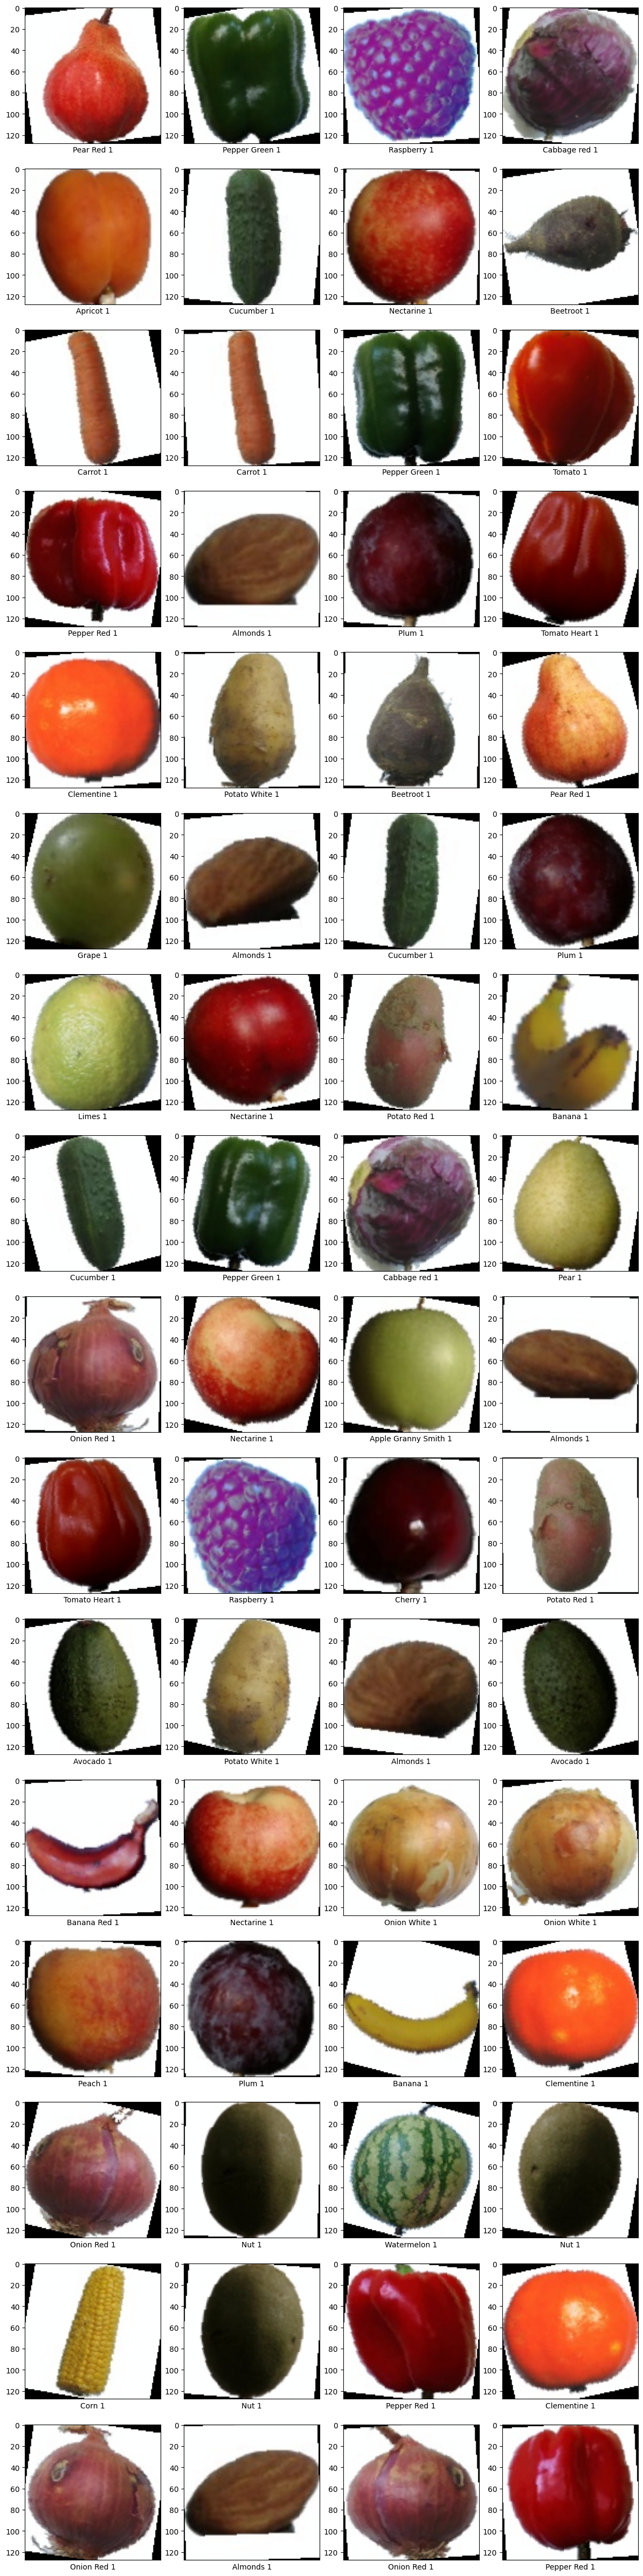

In [26]:
images, classes = get_batches(dataloader["train"])
show_batches(images, classes)

код для отрисовки метрик

In [27]:
def show_metrics(metrics):
    plt.figure(figsize=(12, 8))
    plt.plot(metrics["train"], label="train")
    plt.plot(metrics["val"], label="val")
    plt.grid()
    plt.legend()
    plt.show()

Функция обучения

In [28]:
def train(model, device, train_loader, optimizer, criterion, epoch, WANDB):
    model.train()
    train_loss = 0
    correct = 0
    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    train_accuracy = correct / len(train_loader.dataset)

    tqdm.write(
        "\nTrain set: Average loss: {:.4f}, Accuracy: {:.4f}%".format(
            train_loss, 100.0 * correct / len(train_loader.dataset)
        )
    )

    if WANDB:
        wandb.log(
            {
                "train_loss": train_loss,
                "train_accuracy": correct / len(train_loader.dataset),
            }
        )

Функция теста

In [29]:
def test(model, device, test_loader, criterion, WANDB, split_name="test"):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss = test_loss / len(test_loader)
    test_accuracy = correct / len(test_loader.dataset)

    tqdm.write(
        "{} set: Average loss: {:.4f}, Accuracy: {:.4f}%".format(
            split_name, test_loss, 100.0 * correct / len(test_loader.dataset)
        )
    )

    if WANDB:
        wandb.log(
            {f"{split_name}_loss": test_loss, f"{split_name}_accuracy": test_accuracy}
        )
    return test_loss, test_accuracy

In [30]:
def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            output = model(data)
            pred = output.argmax(dim=1)

            y_true.extend(target.numpy())
            y_pred.extend(pred.cpu().numpy())

    return y_true, y_pred

In [31]:
def main_fruits(model, model_name):
    if CFG.wandb:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(
            project=CFG.project,
            entity=CFG.entity,
            reinit=True,
            config=class2dict(CFG),
            name=model_name,
        )

    use_cuda = torch.cuda.is_available()

    seed_everything(CFG.seed)

    device = torch.device("cuda" if use_cuda else "cpu")

    kwargs = {"num_workers": CFG.num_workers, "pin_memory": True} if use_cuda else {}

    model = model.to(device)

    if CFG.wandb:
        wandb.watch(model, log="all")
    optimizer = optim.Adam(model.parameters(), lr=CFG.lr)

    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, CFG.num_epochs + 1):
        print("\nEpoch:", epoch)
        train(
            model, device, dataloader["train"], optimizer, criterion, epoch, CFG.wandb
        )
        test(model, device, dataloader["val"], criterion, CFG.wandb, split_name="val")

    print("Обучение завершено!")

    test_loss, test_accuracy = test(
        model, device, dataloader["test"], criterion, CFG.wandb, split_name="test"
    )

    y_true, y_pred = get_predictions(model, dataloader["test"], device)

    report = classification_report(
        y_true,
        y_pred,
        target_names=dataset_classes,
        output_dict=True,
    )

    report = pd.DataFrame(report).transpose()
    display(report)

    if CFG.wandb:
        wandb.log({"classification_report": wandb.Table(dataframe=report)})

    model_path = f"{model_name}.pth"
    torch.save(model.state_dict(), model_path)

    if CFG.wandb:
        artifact = wandb.Artifact(model_name, type="model")
        artifact.add_file(model_path)
        wandb.log_artifact(artifact)
        wandb.finish()
    return test_loss, test_accuracy

In [32]:
results = []

Первая простая сверточная сеть

In [33]:
class FirstCNN(torch.nn.Module):
    def __init__(self, n):
        super(FirstCNN, self).__init__()

        self.conv1 = torch.nn.Conv2d(3, 16, 3, padding=1)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2, 2)

        self.conv2 = torch.nn.Conv2d(16, 32, 3, padding=1)
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2, 2)

        self.conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.act3 = torch.nn.ReLU()

        self.fc1 = torch.nn.Linear(32 * 32 * 64, 256)
        self.act4 = torch.nn.Tanh()

        self.fc2 = torch.nn.Linear(256, 64)
        self.act5 = torch.nn.Tanh()

        self.fc3 = torch.nn.Linear(64, n)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.act3(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
        x = self.fc1(x)
        x = self.act4(x)
        x = self.fc2(x)
        x = self.act5(x)
        x = self.fc3(x)

        return x

In [34]:
model_CNN = FirstCNN(n)

In [35]:
summary(
    model=model_CNN,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
FirstCNN                                 [64, 3, 128, 128]    [64, 36]             --                   True
├─Conv2d: 1-1                            [64, 3, 128, 128]    [64, 16, 128, 128]   448                  True
├─ReLU: 1-2                              [64, 16, 128, 128]   [64, 16, 128, 128]   --                   --
├─MaxPool2d: 1-3                         [64, 16, 128, 128]   [64, 16, 64, 64]     --                   --
├─Conv2d: 1-4                            [64, 16, 64, 64]     [64, 32, 64, 64]     4,640                True
├─ReLU: 1-5                              [64, 32, 64, 64]     [64, 32, 64, 64]     --                   --
├─MaxPool2d: 1-6                         [64, 32, 64, 64]     [64, 32, 32, 32]     --                   --
├─Conv2d: 1-7                            [64, 32, 32, 32]     [64, 64, 32, 32]     18,496               True
├─ReLU: 1-8           

In [36]:
test_loss, test_accuracy = main_fruits(model_CNN, "FirstCNN")
results.append(["FirstCNN", test_loss, test_accuracy])


Epoch: 1


100%|██████████| 94/94 [00:12<00:00,  7.24it/s]



Train set: Average loss: 1.8746, Accuracy: 76.8692%
val set: Average loss: 0.9433, Accuracy: 99.0548%

Epoch: 2


100%|██████████| 94/94 [00:14<00:00,  6.53it/s]



Train set: Average loss: 0.6065, Accuracy: 99.3491%
val set: Average loss: 0.3651, Accuracy: 99.8110%

Epoch: 3


...


Train set: Average loss: 0.1412, Accuracy: 99.9666%
val set: Average loss: 0.1060, Accuracy: 100.0000%

Epoch: 5


100%|██████████| 94/94 [00:12<00:00,  7.35it/s]



Train set: Average loss: 0.0901, Accuracy: 99.9666%
val set: Average loss: 0.0711, Accuracy: 100.0000%
Обучение завершено!
test set: Average loss: 0.2494, Accuracy: 94.8313%


,precision,recall,f1-score,support
Almonds 1,1.000000,1.000000,1.000000,77.000000
Apple Granny Smith 1,1.000000,1.000000,1.000000,80.000000
Apricot 1,1.000000,1.000000,1.000000,80.000000
Avocado 1,0.924242,0.762500,0.835616,80.000000
Beetroot 1,0.951613,0.737500,0.830986,80.000000
Banana 1,1.000000,0.750000,0.857143,80.000000
Banana Red 1,1.000000,0.900000,0.947368,80.000000
Cabbage red 1,0.777778,1.000000,0.875000,49.000000
Orange 2,0.974684,0.962500,0.968553,80.000000
Lemon 1,1.000000,1.000000,1.000000,80.000000


test_accuracy,▁
test_loss,▁
train_accuracy,▁████
train_loss,█▃▂▁▁
val_accuracy,▁▇███
val_loss,█▃▂▁▁
test_accuracy,0.94831
test_loss,0.24944
train_accuracy,0.99967
train_loss,0.09006
val_accuracy,1


Вторая модель с BatchNorm и Dropout

In [37]:
class SecondCNN(torch.nn.Module):
    def __init__(self, n):
        super(SecondCNN, self).__init__()

        self.batch_norm0 = torch.nn.BatchNorm2d(3)

        self.conv1 = torch.nn.Conv2d(3, 16, 3, padding=1)
        self.batch_norm1 = torch.nn.BatchNorm2d(16)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2, 2)

        self.conv2 = torch.nn.Conv2d(16, 32, 3, padding=1)
        self.batch_norm2 = torch.nn.BatchNorm2d(32)
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2, 2)

        self.conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.batch_norm3 = torch.nn.BatchNorm2d(64)
        self.act3 = torch.nn.ReLU()

        self.fc1 = torch.nn.Linear(32 * 32 * 64, 256)
        self.batch_norm4 = torch.nn.BatchNorm1d(256)
        self.act4 = torch.nn.Tanh()

        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = torch.nn.Linear(256, 64)
        self.act5 = torch.nn.Tanh()

        self.dropout2 = nn.Dropout(0.25)

        self.fc3 = torch.nn.Linear(64, n)

    def forward(self, x):
        x = self.batch_norm0(x)

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.batch_norm3(x)
        x = self.act3(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
        x = self.fc1(x)
        x = self.batch_norm4(x)
        x = self.act4(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.act5(x)
        x = self.dropout2(x)
        x = self.fc3(x)

        return x

In [38]:
model_CNN2 = SecondCNN(n)

In [39]:
summary(
    model=model_CNN2,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
SecondCNN                                [64, 3, 128, 128]    [64, 36]             --                   True
├─BatchNorm2d: 1-1                       [64, 3, 128, 128]    [64, 3, 128, 128]    6                    True
├─Conv2d: 1-2                            [64, 3, 128, 128]    [64, 16, 128, 128]   448                  True
├─BatchNorm2d: 1-3                       [64, 16, 128, 128]   [64, 16, 128, 128]   32                   True
├─ReLU: 1-4                              [64, 16, 128, 128]   [64, 16, 128, 128]   --                   --
├─MaxPool2d: 1-5                         [64, 16, 128, 128]   [64, 16, 64, 64]     --                   --
├─Conv2d: 1-6                            [64, 16, 64, 64]     [64, 32, 64, 64]     4,640                True
├─BatchNorm2d: 1-7                       [64, 32, 64, 64]     [64, 32, 64, 64]     64                   True
├─ReLU: 1-8       

In [40]:
test_loss, test_accuracy = main_fruits(model_CNN2, "SecondCNN")
results.append(["SecondCNN", test_loss, test_accuracy])


Epoch: 1


100%|██████████| 94/94 [00:12<00:00,  7.26it/s]



Train set: Average loss: 1.8442, Accuracy: 81.2083%
val set: Average loss: 0.8979, Accuracy: 99.8110%

Epoch: 2


100%|██████████| 94/94 [00:12<00:00,  7.25it/s]



Train set: Average loss: 0.6846, Accuracy: 99.6328%
val set: Average loss: 0.3334, Accuracy: 99.9055%

Epoch: 3


...


Train set: Average loss: 0.1783, Accuracy: 100.0000%
val set: Average loss: 0.0915, Accuracy: 100.0000%

Epoch: 5


100%|██████████| 94/94 [00:12<00:00,  7.33it/s]



Train set: Average loss: 0.1156, Accuracy: 100.0000%
val set: Average loss: 0.0595, Accuracy: 100.0000%
Обучение завершено!
test set: Average loss: 0.2118, Accuracy: 96.6260%


,precision,recall,f1-score,support
Almonds 1,1.000000,1.000000,1.000000,77.00000
Apple Granny Smith 1,1.000000,1.000000,1.000000,80.00000
Apricot 1,1.000000,1.000000,1.000000,80.00000
Avocado 1,1.000000,1.000000,1.000000,80.00000
Beetroot 1,1.000000,0.687500,0.814815,80.00000
Banana 1,1.000000,0.725000,0.840580,80.00000
Banana Red 1,1.000000,1.000000,1.000000,80.00000
Cabbage red 1,0.680556,1.000000,0.809917,49.00000
Orange 2,1.000000,1.000000,1.000000,80.00000
Lemon 1,1.000000,1.000000,1.000000,80.00000


test_accuracy,▁
test_loss,▁
train_accuracy,▁████
train_loss,█▃▂▁▁
val_accuracy,▁▅███
val_loss,█▃▂▁▁
test_accuracy,0.96626
test_loss,0.21181
train_accuracy,1
train_loss,0.11559
val_accuracy,1


Третья модель(AlexNet)

In [41]:
from torchvision.models import alexnet
from torchvision.models import AlexNet_Weights

In [42]:
AlexNet = alexnet(weights=AlexNet_Weights.DEFAULT)

In [43]:
summary(
    model=AlexNet,
    input_size=(8, 3, CFG.image_size, CFG.image_size),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable",
    ],
    col_width=20,
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
AlexNet                                  [8, 3, 128, 128]     [8, 1000]            --                   True
├─Sequential: 1-1                        [8, 3, 128, 128]     [8, 256, 3, 3]       --                   True
│    └─Conv2d: 2-1                       [8, 3, 128, 128]     [8, 64, 31, 31]      23,296               True
│    └─ReLU: 2-2                         [8, 64, 31, 31]      [8, 64, 31, 31]      --                   --
│    └─MaxPool2d: 2-3                    [8, 64, 31, 31]      [8, 64, 15, 15]      --                   --
│    └─Conv2d: 2-4                       [8, 64, 15, 15]      [8, 192, 15, 15]     307,392              True
│    └─ReLU: 2-5                         [8, 192, 15, 15]     [8, 192, 15, 15]     --                   --
│    └─MaxPool2d: 2-6                    [8, 192, 15, 15]     [8, 192, 7, 7]       --                   --
│    └─Conv2d: 2-7    

In [44]:
num_in_features = 9216
num_out_features = n

AlexNet.classifier = torch.nn.Linear(num_in_features, num_out_features)
AlexNet.to(DEVICE)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Linear(in_features=9216, out_features=36, bias=True)
)

In [45]:
summary(
    model=AlexNet,
    input_size=(8, 3, CFG.image_size, CFG.image_size),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
AlexNet                                  [8, 3, 128, 128]     [8, 36]              --                   True
├─Sequential: 1-1                        [8, 3, 128, 128]     [8, 256, 3, 3]       --                   True
│    └─Conv2d: 2-1                       [8, 3, 128, 128]     [8, 64, 31, 31]      23,296               True
│    └─ReLU: 2-2                         [8, 64, 31, 31]      [8, 64, 31, 31]      --                   --
│    └─MaxPool2d: 2-3                    [8, 64, 31, 31]      [8, 64, 15, 15]      --                   --
│    └─Conv2d: 2-4                       [8, 64, 15, 15]      [8, 192, 15, 15]     307,392              True
│    └─ReLU: 2-5                         [8, 192, 15, 15]     [8, 192, 15, 15]     --                   --
│    └─MaxPool2d: 2-6                    [8, 192, 15, 15]     [8, 192, 7, 7]       --                   --
│    └─Conv2d: 2-7    

In [46]:
test_loss, test_accuracy = main_fruits(AlexNet, "AlexNet")
results.append(["AlexNet", test_loss, test_accuracy])


Epoch: 1


100%|██████████| 94/94 [00:11<00:00,  7.94it/s]



Train set: Average loss: 0.2348, Accuracy: 94.3258%
val set: Average loss: 0.0079, Accuracy: 99.7164%

Epoch: 2


100%|██████████| 94/94 [00:11<00:00,  8.06it/s]



Train set: Average loss: 0.0363, Accuracy: 99.0988%
val set: Average loss: 0.0114, Accuracy: 99.8110%

Epoch: 3


...


Train set: Average loss: 0.0000, Accuracy: 100.0000%
val set: Average loss: 0.0000, Accuracy: 100.0000%

Epoch: 5


100%|██████████| 94/94 [00:11<00:00,  8.09it/s]



Train set: Average loss: 0.0000, Accuracy: 100.0000%
val set: Average loss: 0.0000, Accuracy: 100.0000%
Обучение завершено!
test set: Average loss: 0.1635, Accuracy: 97.9899%


,precision,recall,f1-score,support
Almonds 1,0.974684,1.000000,0.987179,77.000000
Apple Granny Smith 1,1.000000,1.000000,1.000000,80.000000
Apricot 1,1.000000,1.000000,1.000000,80.000000
Avocado 1,1.000000,1.000000,1.000000,80.000000
Beetroot 1,1.000000,0.862500,0.926174,80.000000
Banana 1,1.000000,1.000000,1.000000,80.000000
Banana Red 1,1.000000,1.000000,1.000000,80.000000
Cabbage red 1,0.816667,1.000000,0.899083,49.000000
Orange 2,1.000000,0.962500,0.980892,80.000000
Lemon 1,1.000000,1.000000,1.000000,80.000000


test_accuracy,▁
test_loss,▁
train_accuracy,▁▇███
train_loss,█▂▁▁▁
val_accuracy,▁▃███
val_loss,▆█▁▁▁
test_accuracy,0.9799
test_loss,0.16348
train_accuracy,1
train_loss,1e-05
val_accuracy,1


EfficientNet_B0

In [47]:
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

In [48]:
EfficientNet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

In [49]:
summary(
    model=EfficientNet,
    input_size=(8, 3, CFG.image_size, CFG.image_size),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
)

Layer (type:depth-idx)                                  Input Shape          Output Shape         Param #              Trainable
EfficientNet                                            [8, 3, 128, 128]     [8, 1000]            --                   True
├─Sequential: 1-1                                       [8, 3, 128, 128]     [8, 1280, 4, 4]      --                   True
│    └─Conv2dNormActivation: 2-1                        [8, 3, 128, 128]     [8, 32, 64, 64]      --                   True
│    │    └─Conv2d: 3-1                                 [8, 3, 128, 128]     [8, 32, 64, 64]      864                  True
│    │    └─BatchNorm2d: 3-2                            [8, 32, 64, 64]      [8, 32, 64, 64]      64                   True
│    │    └─SiLU: 3-3                                   [8, 32, 64, 64]      [8, 32, 64, 64]      --                   --
│    └─Sequential: 2-2                                  [8, 32, 64, 64]      [8, 16, 64, 64]      --                   True
│    

In [50]:
num_in_features = EfficientNet.classifier[1].in_features
num_out_features = n

EfficientNet.classifier[1] = torch.nn.Linear(num_in_features, num_out_features)
EfficientNet.to(DEVICE)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [51]:
summary(
    model=EfficientNet,
    input_size=(8, 3, CFG.image_size, CFG.image_size),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
)

Layer (type:depth-idx)                                  Input Shape          Output Shape         Param #              Trainable
EfficientNet                                            [8, 3, 128, 128]     [8, 36]              --                   True
├─Sequential: 1-1                                       [8, 3, 128, 128]     [8, 1280, 4, 4]      --                   True
│    └─Conv2dNormActivation: 2-1                        [8, 3, 128, 128]     [8, 32, 64, 64]      --                   True
│    │    └─Conv2d: 3-1                                 [8, 3, 128, 128]     [8, 32, 64, 64]      864                  True
│    │    └─BatchNorm2d: 3-2                            [8, 32, 64, 64]      [8, 32, 64, 64]      64                   True
│    │    └─SiLU: 3-3                                   [8, 32, 64, 64]      [8, 32, 64, 64]      --                   --
│    └─Sequential: 2-2                                  [8, 32, 64, 64]      [8, 16, 64, 64]      --                   True
│    

In [52]:
test_loss, test_accuracy = main_fruits(EfficientNet, "EfficientNet_B0")
results.append(["EfficientNet_B0", test_loss, test_accuracy])


Epoch: 1


100%|██████████| 94/94 [00:17<00:00,  5.35it/s]



Train set: Average loss: 0.6128, Accuracy: 92.7236%
val set: Average loss: 0.0053, Accuracy: 100.0000%

Epoch: 2


100%|██████████| 94/94 [00:17<00:00,  5.28it/s]



Train set: Average loss: 0.0098, Accuracy: 99.9332%
val set: Average loss: 0.0023, Accuracy: 100.0000%

Epoch: 3


...


Train set: Average loss: 0.0025, Accuracy: 100.0000%
val set: Average loss: 0.0006, Accuracy: 100.0000%

Epoch: 5


100%|██████████| 94/94 [00:18<00:00,  5.10it/s]



Train set: Average loss: 0.0015, Accuracy: 100.0000%
val set: Average loss: 0.0004, Accuracy: 100.0000%
Обучение завершено!
test set: Average loss: 0.0890, Accuracy: 98.2412%


,precision,recall,f1-score,support
Almonds 1,0.987179,1.000000,0.993548,77.000000
Apple Granny Smith 1,1.000000,1.000000,1.000000,80.000000
Apricot 1,1.000000,1.000000,1.000000,80.000000
Avocado 1,1.000000,1.000000,1.000000,80.000000
Beetroot 1,1.000000,0.787500,0.881119,80.000000
Banana 1,1.000000,1.000000,1.000000,80.000000
Banana Red 1,1.000000,1.000000,1.000000,80.000000
Cabbage red 1,0.742424,1.000000,0.852174,49.000000
Orange 2,1.000000,0.987500,0.993711,80.000000
Lemon 1,1.000000,1.000000,1.000000,80.000000


test_accuracy,▁
test_loss,▁
train_accuracy,▁████
train_loss,█▁▁▁▁
val_accuracy,▁▁▁▁▁
val_loss,█▄▂▁▁
test_accuracy,0.98241
test_loss,0.08896
train_accuracy,1
train_loss,0.00147
val_accuracy,1


In [53]:
import pandas as pd

results = pd.DataFrame(results, columns=["model", "test_loss", "test_accuracy"])
results.sort_values("test_accuracy", ascending=False)

,model,test_loss,test_accuracy
3,EfficientNet_B0,0.088961,0.982412
2,AlexNet,0.163483,0.979899
1,SecondCNN,0.211813,0.966260
0,FirstCNN,0.249444,0.948313


Исходя из всех экспериментов, лучшее качество на тесте получилось у EfficientNet_B0/AlexNet. В сравнении с AlexNet и остальными моделями EfficientNet_B0 показала меньший loss. В целом можно сказать о лучшем качестве извлечения признаков для выбранных классов овощей и фруктов у предобученных моделей.

SecondCNN оказалась лучше FirstCNN, ввиду добавления BatchNorm и Dropout, модель лучше обобщила результат. Лучше сравнивать по test_accuracy, так как модели быстро достигают 100% accuracy на валидационной выборке.